# Introduction

In this notebook, we will explore a real-life big data problem from a Kaggle competition and demonstrate how to optimize the solution using Intel-optimized Scikit-learn (daal4py). We will start by implementing the baseline solution using vanilla Scikit-learn and then compare its performance with the optimized version.

## Objectives
- Identify a suitable Kaggle competition that relies on algorithms optimized in daal4py.
- Implement the baseline solution using vanilla Scikit-learn.
- Optimize the solution using Intel-optimized Scikit-learn.
- Compare the performance and accuracy of both solutions.

## Dataset
We will use the dataset from the Housing Prices Competition for Kaggle Learn Users. The goal is to predict house prices based on various features.

## Steps
1. Load and preprocess the data.
2. Train the model using vanilla Scikit-learn.
3. Optimize the model using Intel-optimized Scikit-learn.
4. Evaluate and compare the results.

In [92]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import time
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor
%matplotlib inline

In [93]:
#Load the data
train_data = pd.read_csv('dataset/train.csv')
test_data = pd.read_csv('dataset/test.csv')

In [94]:
# Get a summary of the training data
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [95]:
train_data.describe(include='object').transpose()

,count,unique,top,freq
MSZoning,1460,5,RL,1151
Street,1460,2,Pave,1454
Alley,91,2,Grvl,50
LotShape,1460,4,Reg,925
LandContour,1460,4,Lvl,1311
Utilities,1460,2,AllPub,1459
LotConfig,1460,5,Inside,1052
LandSlope,1460,3,Gtl,1382
Neighborhood,1460,25,NAmes,225
Condition1,1460,9,Norm,1260


In [96]:
# Split the training and validation set

X = train_data.drop(['Id', 'SalePrice'], axis=1)
y = train_data.SalePrice

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=1)
X_train.shape, X_val.shape, y_train.shape, y_val.shape

((1168, 79), (292, 79), (1168,), (292,))

## Feature Selection

In [97]:
# Identify numeric columns
numeric_features = train_data.select_dtypes(include=['int64', 'float64']).columns.tolist()
print(numeric_features)

['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold', 'SalePrice']


In [98]:
# Identify categorical columns
categorical_features = train_data.select_dtypes(include=['object']).columns.tolist()
print(categorical_features)

['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition']


In [99]:
# Choose features with low cardinality (<10 unique values)

low_cardinality_cols = [cols for cols in X_train.columns if
                   X_train[cols].dtype == 'object' and
                   X_train[cols].nunique() < 10]

X_train[low_cardinality_cols].info()

<class 'pandas.core.frame.DataFrame'>
Index: 1168 entries, 921 to 1061
Data columns (total 40 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   MSZoning       1168 non-null   object
 1   Street         1168 non-null   object
 2   Alley          71 non-null     object
 3   LotShape       1168 non-null   object
 4   LandContour    1168 non-null   object
 5   Utilities      1168 non-null   object
 6   LotConfig      1168 non-null   object
 7   LandSlope      1168 non-null   object
 8   Condition1     1168 non-null   object
 9   Condition2     1168 non-null   object
 10  BldgType       1168 non-null   object
 11  HouseStyle     1168 non-null   object
 12  RoofStyle      1168 non-null   object
 13  RoofMatl       1168 non-null   object
 14  MasVnrType     482 non-null    object
 15  ExterQual      1168 non-null   object
 16  ExterCond      1168 non-null   object
 17  Foundation     1168 non-null   object
 18  BsmtQual       1138 non-null   

In [100]:
# Ensure the validation set does not contain unseen values compared to the training set

categorical_cols = [cols for cols in low_cardinality_cols if
                   set(X_val[cols]).issubset(set(X_train[cols]))]

X_train[categorical_cols].info()

<class 'pandas.core.frame.DataFrame'>
Index: 1168 entries, 921 to 1061
Data columns (total 38 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   MSZoning       1168 non-null   object
 1   Street         1168 non-null   object
 2   Alley          71 non-null     object
 3   LotShape       1168 non-null   object
 4   LandContour    1168 non-null   object
 5   Utilities      1168 non-null   object
 6   LotConfig      1168 non-null   object
 7   LandSlope      1168 non-null   object
 8   Condition1     1168 non-null   object
 9   Condition2     1168 non-null   object
 10  BldgType       1168 non-null   object
 11  HouseStyle     1168 non-null   object
 12  RoofStyle      1168 non-null   object
 13  MasVnrType     482 non-null    object
 14  ExterQual      1168 non-null   object
 15  ExterCond      1168 non-null   object
 16  Foundation     1168 non-null   object
 17  BsmtQual       1138 non-null   object
 18  BsmtCond       1138 non-null   

In [101]:
# Ensure the test set does not contain unseen values as well
# Also, make sure the columns we select do not have null values in the test set

test_categorical_cols = [cols for cols in categorical_cols if
                        set(test_data[cols]).issubset(set(X_train[cols])) and
                        test_data[cols].isnull().any() == False]

X_train[test_categorical_cols].info()

<class 'pandas.core.frame.DataFrame'>
Index: 1168 entries, 921 to 1061
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Street         1168 non-null   object
 1   LotShape       1168 non-null   object
 2   LandContour    1168 non-null   object
 3   LotConfig      1168 non-null   object
 4   LandSlope      1168 non-null   object
 5   Condition1     1168 non-null   object
 6   Condition2     1168 non-null   object
 7   BldgType       1168 non-null   object
 8   HouseStyle     1168 non-null   object
 9   RoofStyle      1168 non-null   object
 10  ExterQual      1168 non-null   object
 11  ExterCond      1168 non-null   object
 12  Foundation     1168 non-null   object
 13  Heating        1168 non-null   object
 14  CentralAir     1168 non-null   object
 15  Electrical     1167 non-null   object
 16  PavedDrive     1168 non-null   object
 17  SaleCondition  1168 non-null   object
dtypes: object(18)
memory usage: 173

In [102]:
# Select categorical features for the model
train_categorical_cols = ['HouseStyle', 'Foundation','CentralAir']

# How many unique values does each feature have?
for col in train_categorical_cols:
    print('Column: %s \t\t Number of unique values: %d'%(col, X_train[col].nunique()))

Column: HouseStyle 		 Number of unique values: 8
Column: Foundation 		 Number of unique values: 6
Column: CentralAir 		 Number of unique values: 2


## Preprocessing

In [105]:
# Define features and target
numerical_cols = ['LotArea', 'OverallQual', 'YearBuilt', '1stFlrSF', '2ndFlrSF', 'GarageArea', 'BedroomAbvGr', 'FullBath', 'TotalBsmtSF', 'WoodDeckSF']
categorical_cols = ['HouseStyle', 'Foundation', 'CentralAir']
target = 'SalePrice'

# Define a function to preprocess numerical features
def preprocess_numerical(X):
    X = X.copy()
    if 'TotRmsAbvGrd' in X.columns and 'BedroomAbvGr' in X.columns:
        X['RmsAbvGrd'] = X['TotRmsAbvGrd'] - X['BedroomAbvGr']
        X.drop('TotRmsAbvGrd', axis=1, inplace=True)
    return X

# Update numerical_cols to include 'RmsAbvGrd' instead of 'TotRmsAbvGrd'
numerical_cols.append('RmsAbvGrd')

# Preprocessing pipeline for numerical features
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

# Preprocessing pipeline for categorical features
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combine preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

# Apply preprocessing to training and validation sets
X_train = preprocess_numerical(X_train)
X_val = preprocess_numerical(X_val)

# Print column names to verify
print("Columns in X_train after preprocessing:", X_train.columns)
print("Columns in X_val after preprocessing:", X_val.columns)

X_train_preprocessed = preprocessor.fit_transform(X_train)
X_val_preprocessed = preprocessor.transform(X_val)

# Dimensionality reduction with PCA
pca = PCA(n_components=10)
X_train_reduced = pca.fit_transform(X_train_preprocessed)
X_val_reduced = pca.transform(X_val_preprocessed)

Columns in X_train after preprocessing: Index(['MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley',
       'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope',
       'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle',
       'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle',
       'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea',
       'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond',
       'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC',
       'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
       'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath',
       'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'Functional',
       'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt',
       'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond',


## Vanilla Scikit-learn

In [114]:
# Vanilla Scikit-learn
print("Vanilla Scikit-learn:")
start_time = time.time()
model_vanilla = Ridge()
model_vanilla.fit(X_train_reduced, y_train)
y_pred_vanilla = model_vanilla.predict(X_val_reduced)
mse_vanilla = mean_squared_error(y_val, y_pred_vanilla)
end_time = time.time()
training_time_vanilla = end_time - start_time
print(f'Mean Squared Error: {mse_vanilla}')
print(f'Training Time: {training_time_vanilla} seconds')

Vanilla Scikit-learn:
Mean Squared Error: 1358410933.6855457
Training Time: 0.003008604049682617 seconds


## Intel-optimized Scikit-learn

In [115]:
# Intel-optimized Scikit-learn
from sklearnex import patch_sklearn
patch_sklearn()

print("\nIntel-optimized Scikit-learn:")
start_time = time.time()
model_intel = Ridge()
model_intel.fit(X_train_reduced, y_train)
y_pred_intel = model_intel.predict(X_val_reduced)
mse_intel = mean_squared_error(y_val, y_pred_intel)
end_time = time.time()
training_time_intel = end_time - start_time
print(f'Mean Squared Error: {mse_intel}')
print(f'Training Time: {training_time_intel} seconds')


Intel-optimized Scikit-learn:
Mean Squared Error: 1358410933.6855457
Training Time: 0.0019998550415039062 seconds


Intel(R) Extension for Scikit-learn* enabled (https://github.com/uxlfoundation/scikit-learn-intelex)


In [119]:
# Compare results
print("\nComparison:")
print(f'Vanilla Scikit-learn MSE: {mse_vanilla}')
print(f'Intel-optimized Scikit-learn MSE: {mse_intel}')
print(f'Vanilla Scikit-learn Training Time: {training_time_vanilla} seconds')
print(f'Intel-optimized Scikit-learn Training Time: {training_time_intel} seconds')


Comparison:
Vanilla Scikit-learn MSE: 1358410933.6855457
Intel-optimized Scikit-learn MSE: 1358410933.6855457
Vanilla Scikit-learn Training Time: 0.003008604049682617 seconds
Intel-optimized Scikit-learn Training Time: 0.0019998550415039062 seconds


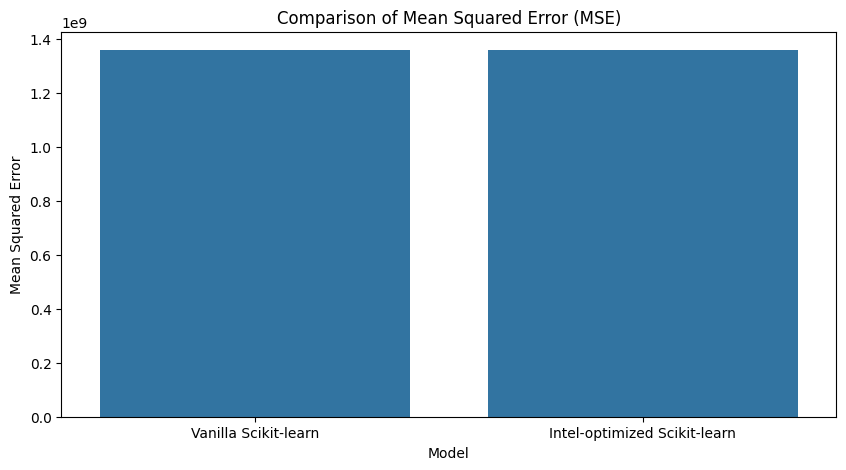

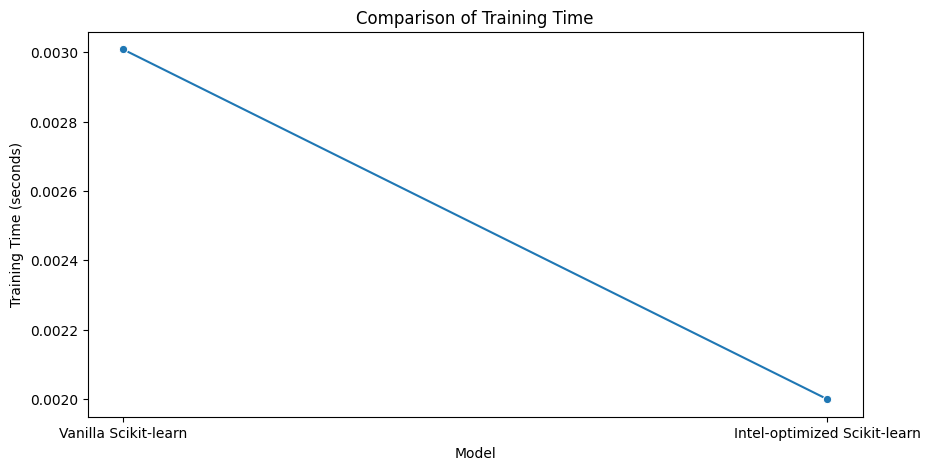

In [120]:
results = {
    'Model': ['Vanilla Scikit-learn', 'Intel-optimized Scikit-learn'],
    'MSE': [mse_vanilla, mse_intel],
    'Training Time (s)': [training_time_vanilla, training_time_intel]
}

# Convert to DataFrame
results_df = pd.DataFrame(results)

# Bar plot for MSE
plt.figure(figsize=(10, 5))
sns.barplot(x='Model', y='MSE', data=results_df)
plt.title('Comparison of Mean Squared Error (MSE)')
plt.ylabel('Mean Squared Error')
plt.show()

# Line plot for Training Time
plt.figure(figsize=(10, 5))
sns.lineplot(x='Model', y='Training Time (s)', data=results_df, marker='o')
plt.title('Comparison of Training Time')
plt.ylabel('Training Time (seconds)')
plt.show()